In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [3]:
df = pd.read_csv("D://Nike_Sales_Uncleaned.csv")
df.head()

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
0,2000,Kids,Training,SuperRep Go,M,NaN,NaN,0.47,0.0,2024-03-09,Online,bengaluru,-770.45
1,2001,Women,Soccer,Tiempo Legend,M,3.0,4957.93,NaN,0.0,2024-07-09,Retail,Hyd,-112.53
2,2002,Women,Soccer,Premier III,M,4.0,NaN,NaN,0.0,NaN,Retail,Mumbai,3337.34
3,2003,Kids,Lifestyle,Blazer Mid,L,NaN,9673.57,NaN,0.0,04-10-2024,Online,Pune,3376.85
4,2004,Kids,Running,React Infinity,XL,NaN,NaN,NaN,0.0,2024/09/12,Retail,Delhi,187.89


In [4]:
#Data Cleaning
# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Remove duplicates
df = df.drop_duplicates()

# Check missing values
df.isnull().sum()

order_id               0
gender_category        0
product_line           0
product_name           0
size                 510
units_sold          1235
mrp                 1254
discount_applied    1668
revenue                0
order_date           616
sales_channel          0
region                 0
profit                 0
dtype: int64

In [10]:
# If Date column exits
df['order_date'] = pd.to_datetime(df['order_date'],errors='coerce')

In [11]:
#KPI metrics
total_revenue = df['revenue'].sum()
total_orders = df.shape[0]
avg_order_value = df['revenue'].mean()

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Average Order Value:", avg_order_value)

Total Revenue: 687184.29
Total Orders: 2500
Average Order Value: 274.873716


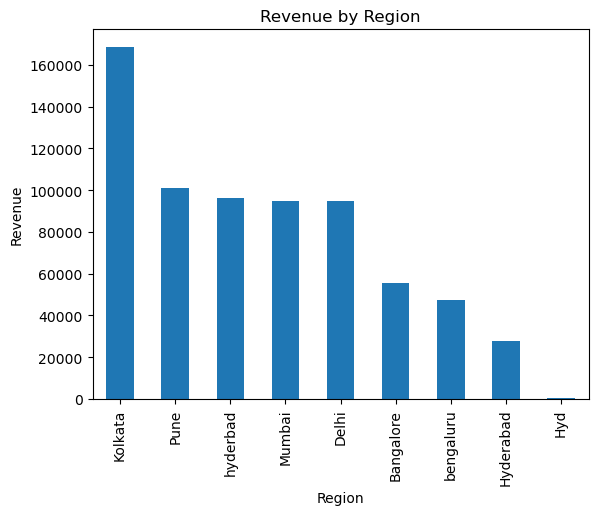

In [19]:
#sales by region
region_sales = df.groupby('region')['revenue'].sum().sort_values(ascending=False)

plt.figure()
region_sales.plot(kind='bar')
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.savefig("revenue_by_region.png", bbox_inches='tight')
plt.show()

In [14]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['order_id', 'gender_category', 'product_line', 'product_name', 'size',
       'units_sold', 'mrp', 'discount_applied', 'revenue', 'order_date',
       'sales_channel', 'region', 'profit'],
      dtype='object')

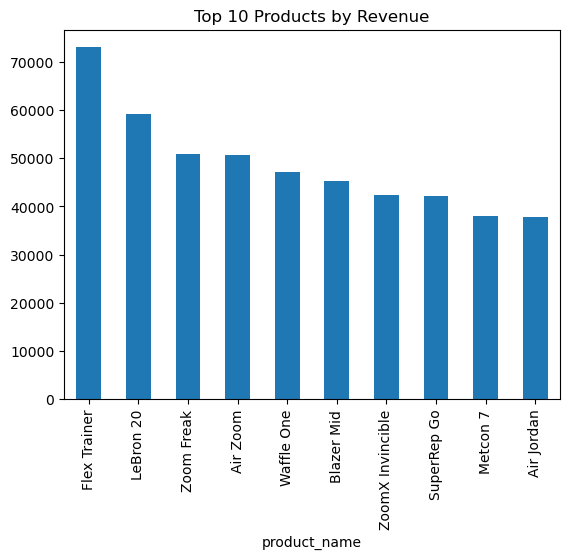

In [20]:
#Top 10 products
top_products = df.groupby('product_name')['revenue'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_products.plot(kind='bar')
plt.title("Top 10 Products by Revenue")
plt.savefig("top_10_products.png", bbox_inches='tight')
plt.show()

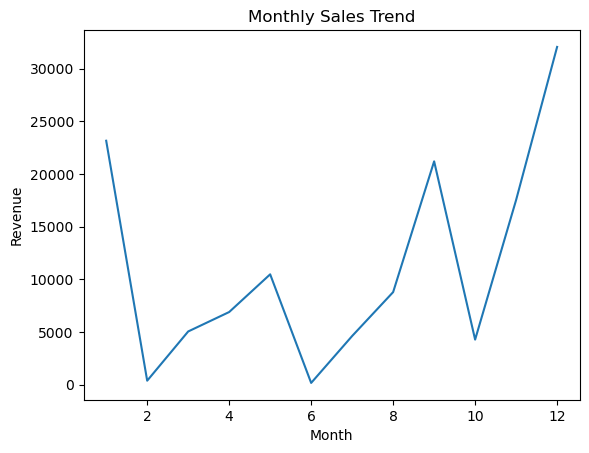

In [21]:
#monthly sales trend
df['month'] = df['order_date'].dt.month
monthly_sales = df.groupby('month')['revenue'].sum()

plt.figure()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.savefig("monthly_sales_trend.png", bbox_inches='tight')
plt.show()

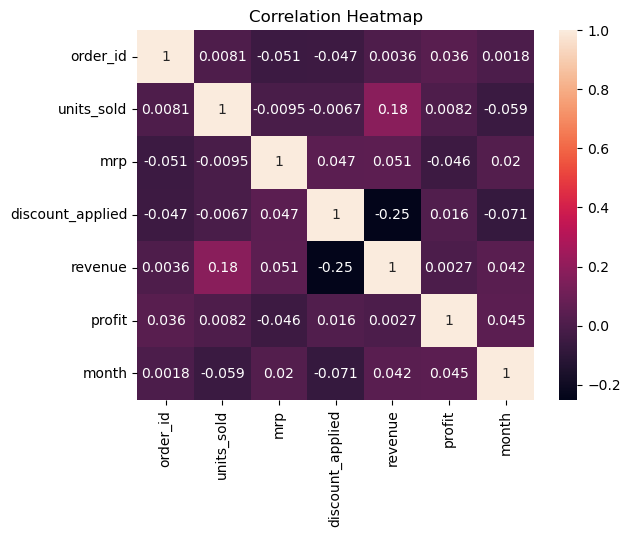

In [22]:
#corelation heatmap
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png", bbox_inches='tight')
plt.show()